# EDA Export For Slides
Notebook này dùng để chạy EDA và xuất ảnh biểu đồ phục vụ slide thuyết trình.

## Team đã tiền xử lý dữ liệu như thế nào?
1. Đọc dữ liệu gốc từ `data/raw/netflix_movies_detailed_up_to_2025.csv`.
2. Loại cột `duration` vì thiếu 100%.
3. Loại các dòng thiếu ở các cột trọng yếu: `country`, `cast`, `director`, `description`, `genres`.
4. Chuẩn hóa kiểu dữ liệu số và chuẩn hóa mã ngôn ngữ sang tên ngôn ngữ đầy đủ.
5. Tách các cột đa giá trị thành bridge tables: `movie_genres`, `movie_countries`, `movie_directors`, `movie_casts`.
6. Lưu dữ liệu trung gian vào `data/interim/movies_cleaned.csv` và dữ liệu cuối vào `data/processed/movies.csv`.

In [15]:
from pathlib import Path
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

warnings.filterwarnings('ignore', category=FutureWarning, module='seaborn')
warnings.filterwarnings('ignore', category=FutureWarning, module='pandas')

sns.set_theme(style='whitegrid', context='talk')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['savefig.dpi'] = 220

def find_repo_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in [start, *start.parents]:
        if (candidate / 'data' / 'raw').exists() and (candidate / 'data' / 'processed').exists():
            return candidate
    raise FileNotFoundError('Không tìm thấy thư mục gốc của dự án chứa data/raw và data/processed')

ROOT_DIR = find_repo_root(Path.cwd())
RAW_PATH = ROOT_DIR / 'data' / 'raw' / 'netflix_movies_detailed_up_to_2025.csv'
MOVIES_PATH = ROOT_DIR / 'data' / 'processed' / 'movies.csv'
COUNTRIES_PATH = ROOT_DIR / 'data' / 'processed' / 'movie_countries.csv'
GENRES_PATH = ROOT_DIR / 'data' / 'processed' / 'movie_genres.csv'
DIRECTORS_PATH = ROOT_DIR / 'data' / 'processed' / 'movie_directors.csv'
CASTS_PATH = ROOT_DIR / 'data' / 'processed' / 'movie_casts.csv'

OUT_DIR = ROOT_DIR / 'data' / 'outputs' / 'slides' / 'eda_images'
OUT_DIR.mkdir(parents=True, exist_ok=True)

print(f'ROOT_DIR: {ROOT_DIR}')
print(f'OUT_DIR: {OUT_DIR}')

ROOT_DIR: C:\Users\ACER\Desktop\Work\Project\DataVis\Mid\Dashboard-Mid
OUT_DIR: C:\Users\ACER\Desktop\Work\Project\DataVis\Mid\Dashboard-Mid\data\outputs\slides\eda_images


In [2]:
raw_df = pd.read_csv(RAW_PATH)
movies_df = pd.read_csv(MOVIES_PATH)
countries_df = pd.read_csv(COUNTRIES_PATH)
genres_df = pd.read_csv(GENRES_PATH)
directors_df = pd.read_csv(DIRECTORS_PATH)
casts_df = pd.read_csv(CASTS_PATH)

for col in ['release_year', 'vote_average', 'popularity', 'vote_count', 'budget', 'revenue']:
    if col in movies_df.columns:
        movies_df[col] = pd.to_numeric(movies_df[col], errors='coerce')

print('Raw shape:', raw_df.shape)
print('Processed shape:', movies_df.shape)
print('Countries bridge shape:', countries_df.shape)
print('Genres bridge shape:', genres_df.shape)
print('Directors bridge shape:', directors_df.shape)
print('Casts bridge shape:', casts_df.shape)

Raw shape: (16000, 18)
Processed shape: (15239, 18)
Countries bridge shape: (21353, 2)
Genres bridge shape: (36340, 2)
Directors bridge shape: (16902, 2)
Casts bridge shape: (74862, 2)


In [3]:
missing_cols = ['duration', 'country', 'cast', 'director', 'description', 'genres']
missing_raw = raw_df[missing_cols].isna().sum()
removed_rows = len(raw_df) - len(movies_df)
removed_pct = (removed_rows / len(raw_df)) * 100

summary_df = pd.DataFrame({
    'Metric': [
        'Raw rows', 'Raw columns', 'Processed rows', 'Processed columns',
        'Removed rows', 'Removed percent', 'Release year min', 'Release year max',
        'Unique languages', 'ROI-eligible movies (budget>5000 & revenue>0)'
    ],
    'Value': [
        len(raw_df),
        raw_df.shape[1],
        len(movies_df),
        movies_df.shape[1],
        removed_rows,
        f'{removed_pct:.2f}%',
        int(movies_df['release_year'].min()),
        int(movies_df['release_year'].max()),
        movies_df['language_name'].nunique(),
        int(((movies_df['budget'] > 5000) & (movies_df['revenue'] > 0)).sum())
    ]
})

bridge_summary_df = pd.DataFrame({
    'Table': ['movie_casts', 'movie_directors', 'movie_countries', 'movie_genres'],
    'Rows': [len(casts_df), len(directors_df), len(countries_df), len(genres_df)],
    'Unique entities': [
        casts_df['cast_name'].nunique(),
        directors_df['director_name'].nunique(),
        countries_df['country_name'].nunique(),
        genres_df['genre'].nunique()
    ]
})

print('Missing values (raw):')
display(missing_raw.to_frame('Missing count'))

print('Summary metrics:')
display(summary_df)

print('Bridge tables summary:')
display(bridge_summary_df)

Missing values (raw):


,Missing count
duration,16000
country,466
cast,204
director,132
description,132
genres,107


Summary metrics:


,Metric,Value
0,Raw rows,16000
1,Raw columns,18
2,Processed rows,15239
3,Processed columns,18
4,Removed rows,761
5,Removed percent,4.76%
6,Release year min,2010
7,Release year max,2025
8,Unique languages,68
9,ROI-eligible movies (budget>5000 & revenue>0),3524


Bridge tables summary:


,Table,Rows,Unique entities
0,movie_casts,74862,33953
1,movie_directors,16902,9631
2,movie_countries,21353,133
3,movie_genres,36340,19


In [4]:
generated_files = []

def save_and_show(filename: str):
    path = OUT_DIR / filename
    plt.tight_layout()
    plt.savefig(path, bbox_inches='tight')
    generated_files.append(path.name)
    print(f'Saved: {path}')
    plt.show()
    plt.close()

Saved: C:\Users\ACER\Desktop\Work\Project\DataVis\Mid\Dashboard-Mid\data\outputs\slides\eda_images\00_feature_overview_raw.png


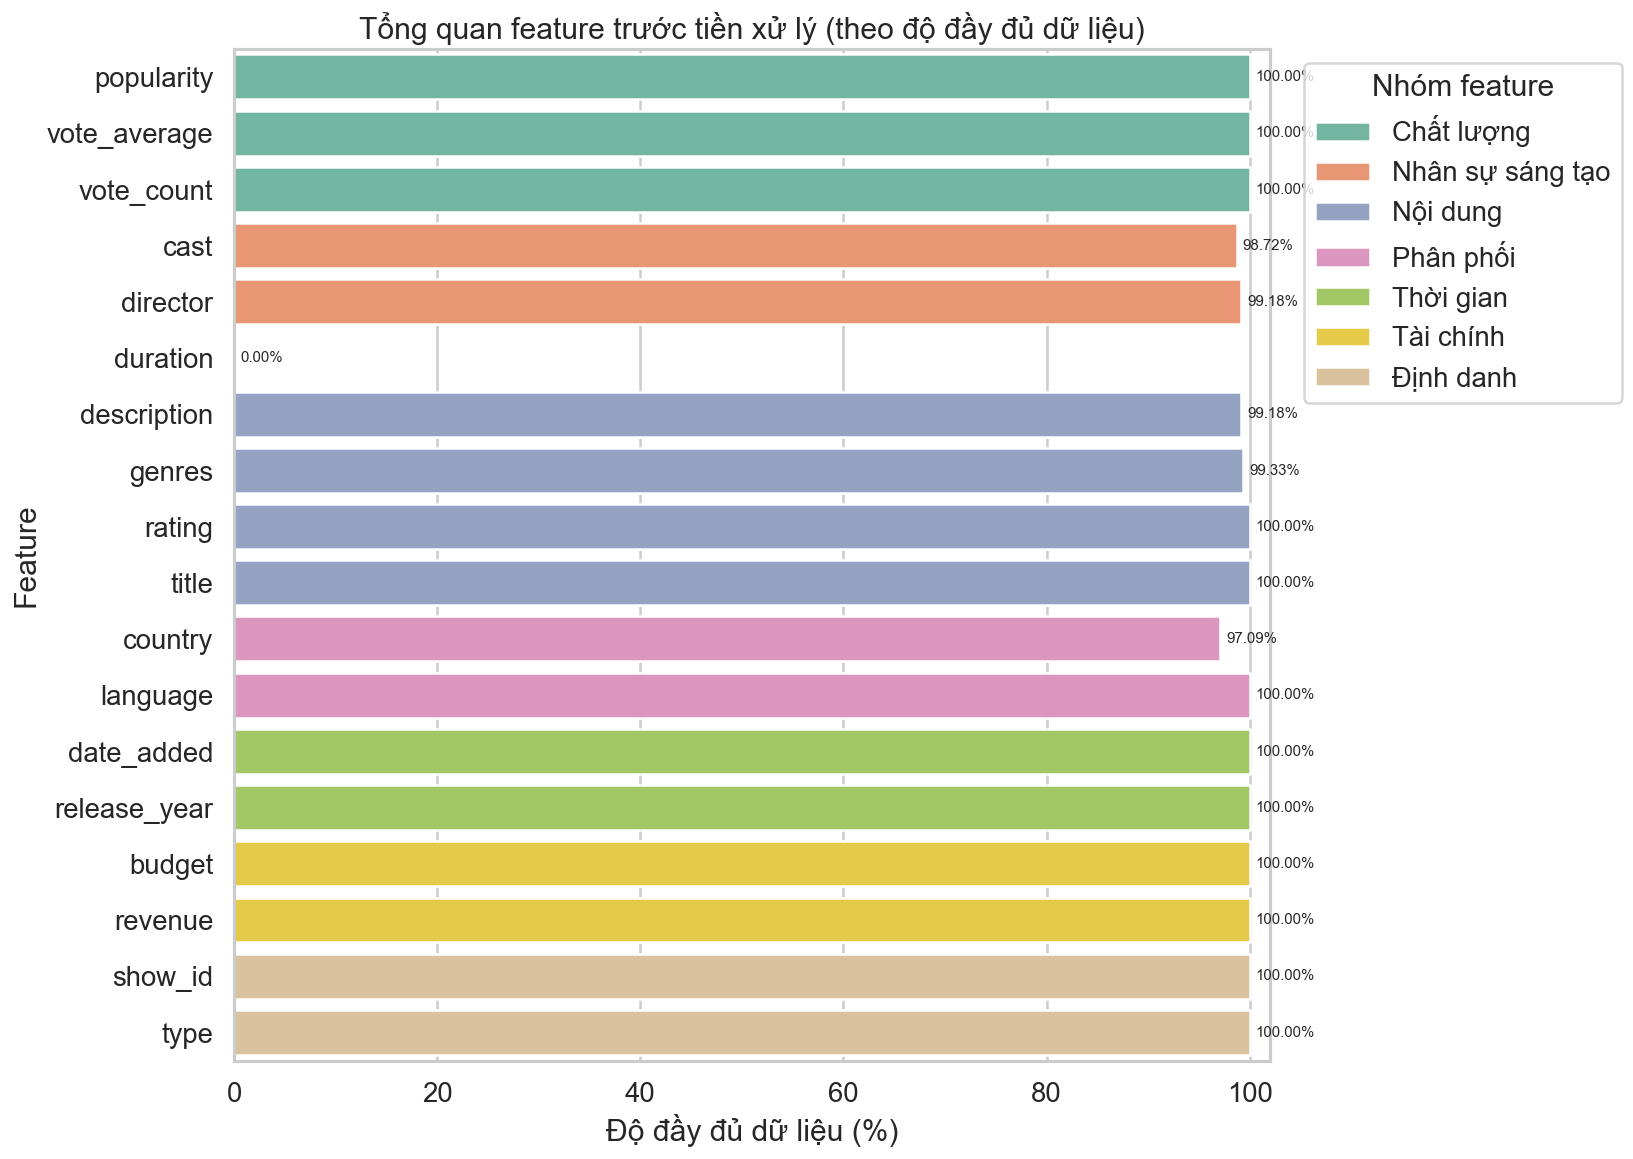

In [18]:
# 00. Tổng quan feature trước tiền xử lý (schema + độ đầy đủ)
feature_group_map = {
    'show_id': 'Định danh',
    'type': 'Định danh',
    'title': 'Nội dung',
    'description': 'Nội dung',
    'director': 'Nhân sự sáng tạo',
    'cast': 'Nhân sự sáng tạo',
    'country': 'Phân phối',
    'language': 'Phân phối',
    'language_code': 'Phân phối',
    'language_name': 'Phân phối',
    'genres': 'Nội dung',
    'date_added': 'Thời gian',
    'release_year': 'Thời gian',
    'rating': 'Nội dung',
    'popularity': 'Chất lượng',
    'vote_count': 'Chất lượng',
    'vote_average': 'Chất lượng',
    'budget': 'Tài chính',
    'revenue': 'Tài chính',
    'duration': 'Nội dung',
}

feature_overview_df = pd.DataFrame({
    'Feature': raw_df.columns,
    'Độ đầy đủ (%)': (100 - raw_df.isna().mean().mul(100)).round(2),
    'Số giá trị thiếu': raw_df.isna().sum(),
}).reset_index(drop=True)
feature_overview_df['Nhóm feature'] = feature_overview_df['Feature'].map(feature_group_map).fillna('Khác')
feature_overview_df = feature_overview_df.sort_values(['Nhóm feature', 'Độ đầy đủ (%)', 'Feature'])

plt.figure(figsize=(14, 10))
ax = sns.barplot(
    data=feature_overview_df,
    x='Độ đầy đủ (%)',
    y='Feature',
    hue='Nhóm feature',
    dodge=False,
    palette='Set2',
)

plt.title('Tổng quan feature trước tiền xử lý (theo độ đầy đủ dữ liệu)')
plt.xlabel('Độ đầy đủ dữ liệu (%)')
plt.ylabel('Feature')
plt.xlim(0, 102)
plt.legend(title='Nhóm feature', bbox_to_anchor=(1.02, 1), loc='upper left')

for patch, (_, row) in zip(ax.patches, feature_overview_df.iterrows()):
    value = row['Độ đầy đủ (%)']
    ax.text(
        patch.get_width() + 0.6,
        patch.get_y() + patch.get_height() / 2,
        f"{value:.2f}%",
        va='center',
        fontsize=9,
    )

save_and_show('00_feature_overview_raw.png')

C:\Users\ACER\AppData\Local\Temp\ipykernel_30060\3310773726.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing_values.index, y=missing_values.values, palette='rocket')


Saved: C:\Users\ACER\Desktop\Work\Project\DataVis\Mid\Dashboard-Mid\data\outputs\slides\eda_images\01_missing_values_raw.png


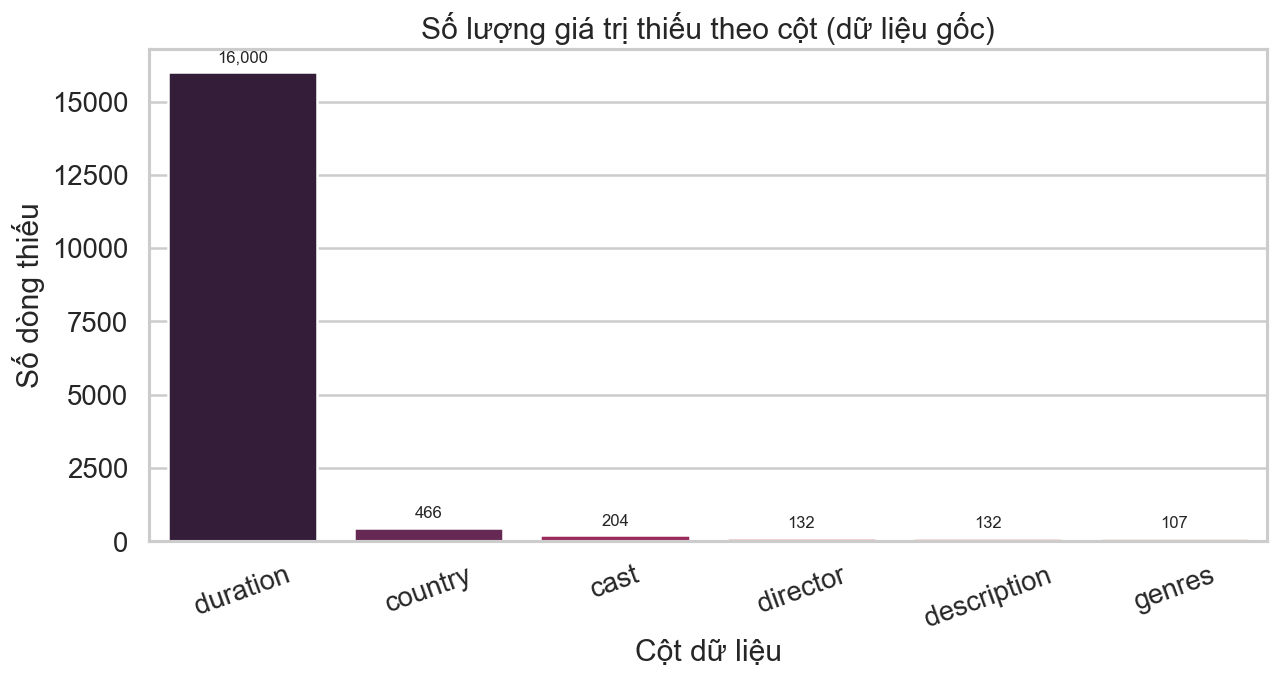

In [16]:
# 01. Missing values trong dữ liệu gốc
missing_values = raw_df[missing_cols].isna().sum().sort_values(ascending=False)

plt.figure(figsize=(11, 6))
sns.barplot(x=missing_values.index, y=missing_values.values, palette='rocket')
plt.title('Số lượng giá trị thiếu theo cột (dữ liệu gốc)')
plt.xlabel('Cột dữ liệu')
plt.ylabel('Số dòng thiếu')
plt.xticks(rotation=20)

y_offset = missing_values.max() * 0.015
for idx, value in enumerate(missing_values.values):
    plt.text(idx, value + y_offset, f'{value:,}', ha='center', va='bottom', fontsize=10)

save_and_show('01_missing_values_raw.png')

Saved: C:\Users\ACER\Desktop\Work\Project\DataVis\Mid\Dashboard-Mid\data\outputs\slides\eda_images\02_release_year_trend.png


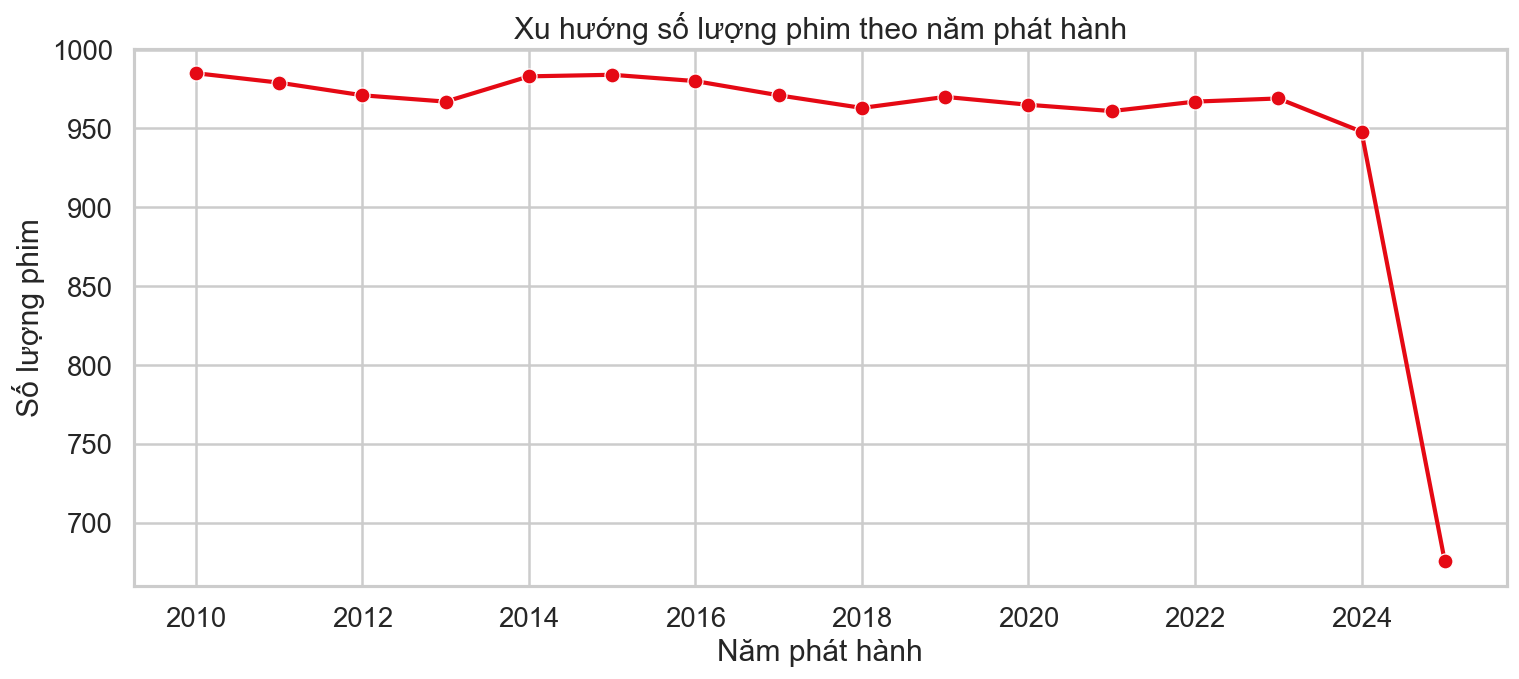

In [6]:
# 02. Xu hướng số lượng phim theo năm phát hành
release_counts = movies_df['release_year'].dropna().astype(int).value_counts().sort_index()

plt.figure(figsize=(13, 6))
sns.lineplot(x=release_counts.index, y=release_counts.values, marker='o', color='#E50914', linewidth=2.5)
plt.title('Xu hướng số lượng phim theo năm phát hành')
plt.xlabel('Năm phát hành')
plt.ylabel('Số lượng phim')

save_and_show('02_release_year_trend.png')

C:\Users\ACER\AppData\Local\Temp\ipykernel_30060\3724508420.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_countries.values, y=top_countries.index, palette='viridis')
d:\Anaconda\envs\torch-gpu\Lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
d:\Anaconda\envs\torch-gpu\Lib\site-packages\seaborn\categorical.py:1273: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping

Saved: C:\Users\ACER\Desktop\Work\Project\DataVis\Mid\Dashboard-Mid\data\outputs\slides\eda_images\03_top_countries.png


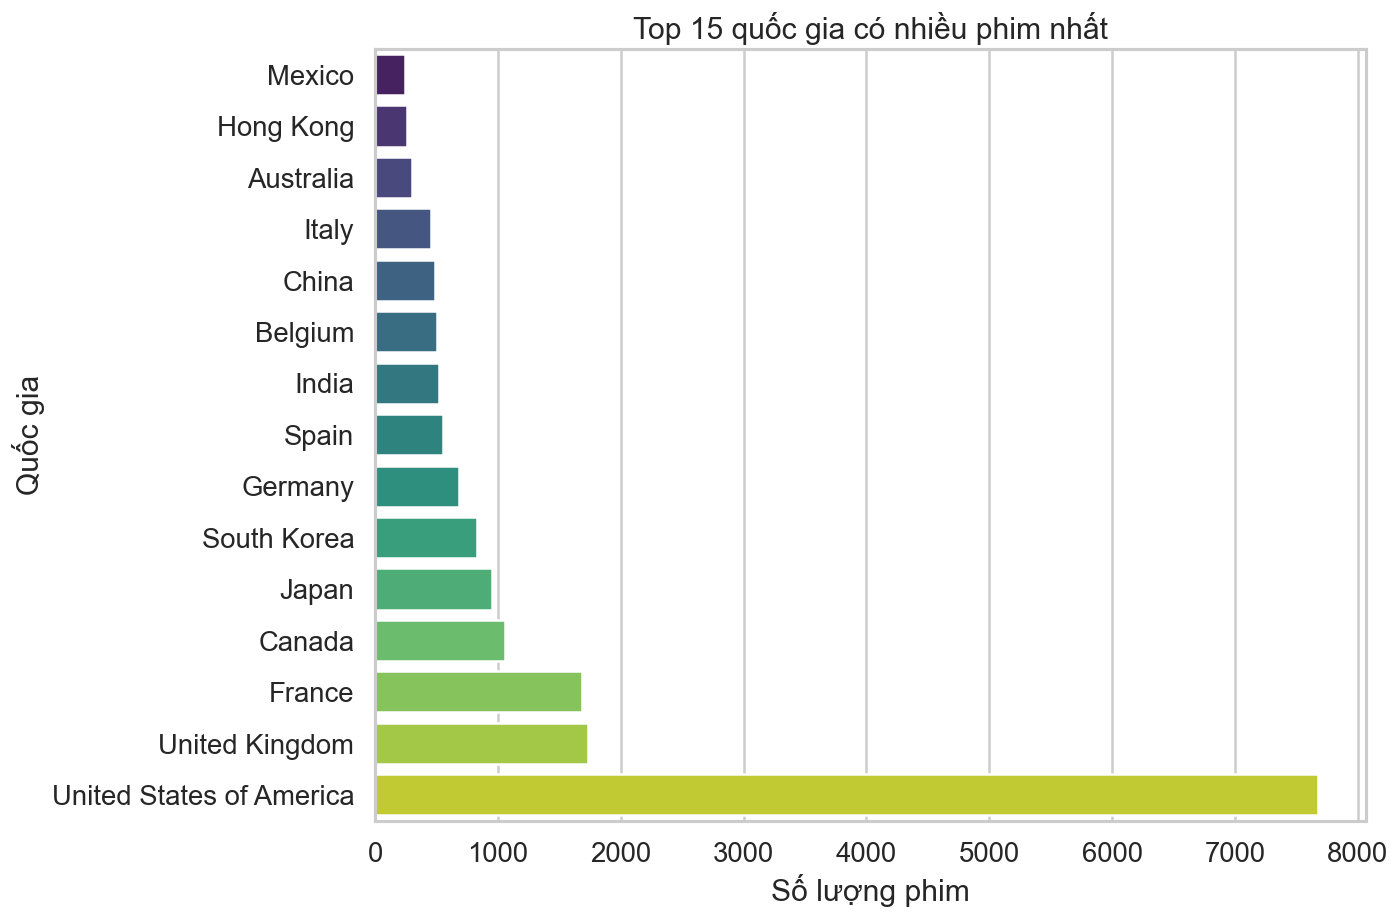

In [7]:
# 03. Top quốc gia theo số lượng phim
top_countries = countries_df['country_name'].value_counts().head(15).sort_values(ascending=True)

plt.figure(figsize=(12, 8))
sns.barplot(x=top_countries.values, y=top_countries.index, palette='viridis')
plt.title('Top 15 quốc gia có nhiều phim nhất')
plt.xlabel('Số lượng phim')
plt.ylabel('Quốc gia')

save_and_show('03_top_countries.png')

C:\Users\ACER\AppData\Local\Temp\ipykernel_30060\2964623215.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_genres.values, y=top_genres.index, palette='magma')
d:\Anaconda\envs\torch-gpu\Lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
d:\Anaconda\envs\torch-gpu\Lib\site-packages\seaborn\categorical.py:1273: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns

Saved: C:\Users\ACER\Desktop\Work\Project\DataVis\Mid\Dashboard-Mid\data\outputs\slides\eda_images\04_top_genres.png


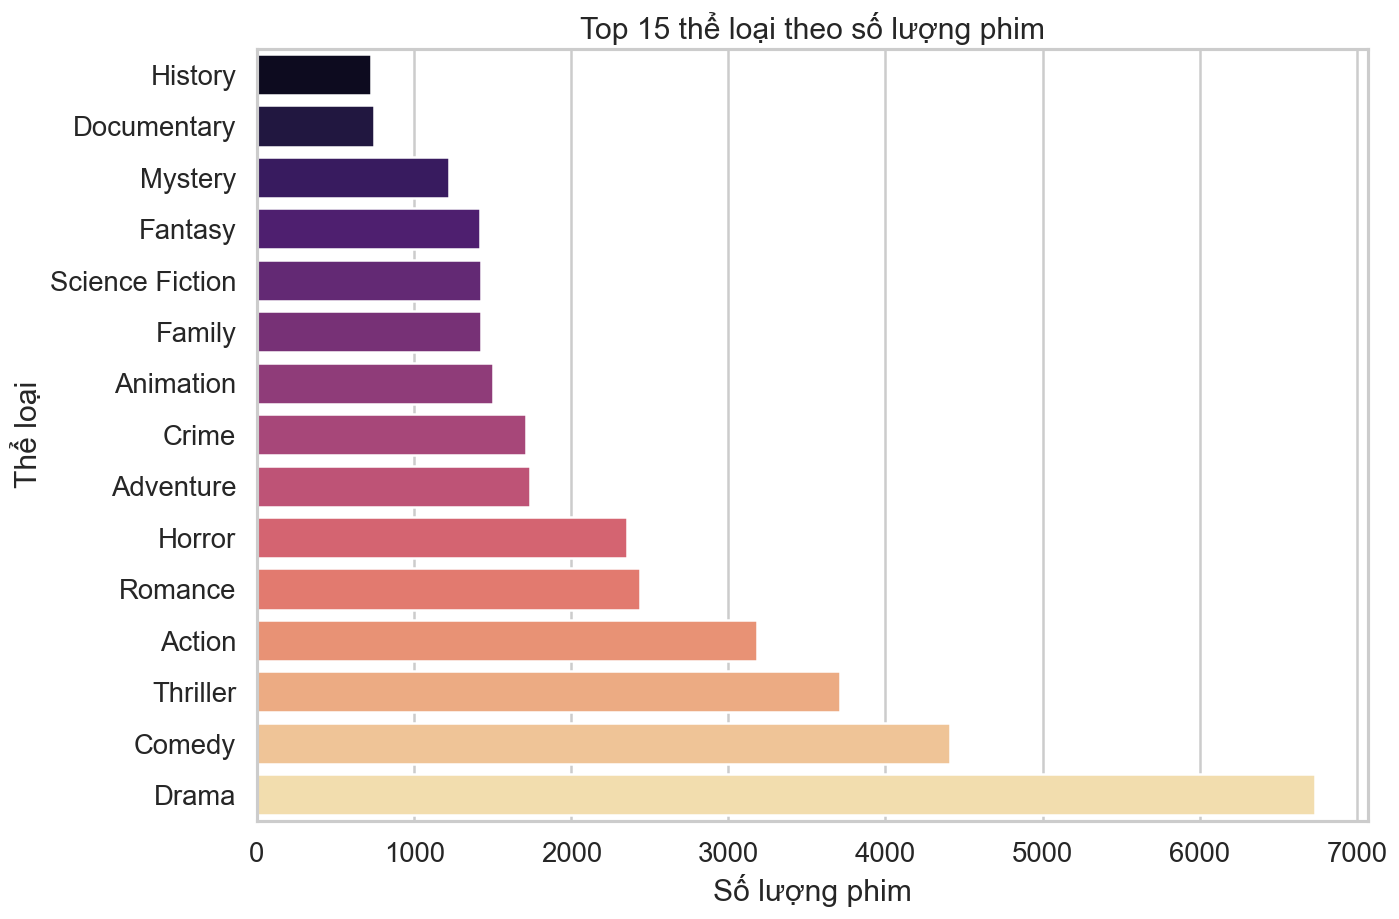

In [8]:
# 04. Top thể loại theo số lượng phim
top_genres = genres_df['genre'].value_counts().head(15).sort_values(ascending=True)

plt.figure(figsize=(12, 8))
sns.barplot(x=top_genres.values, y=top_genres.index, palette='magma')
plt.title('Top 15 thể loại theo số lượng phim')
plt.xlabel('Số lượng phim')
plt.ylabel('Thể loại')

save_and_show('04_top_genres.png')

C:\Users\ACER\AppData\Local\Temp\ipykernel_30060\3000328908.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_languages.index, y=top_languages.values, palette='crest')
d:\Anaconda\envs\torch-gpu\Lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
d:\Anaconda\envs\torch-gpu\Lib\site-packages\seaborn\categorical.py:1273: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping c

Saved: C:\Users\ACER\Desktop\Work\Project\DataVis\Mid\Dashboard-Mid\data\outputs\slides\eda_images\05_top_languages.png


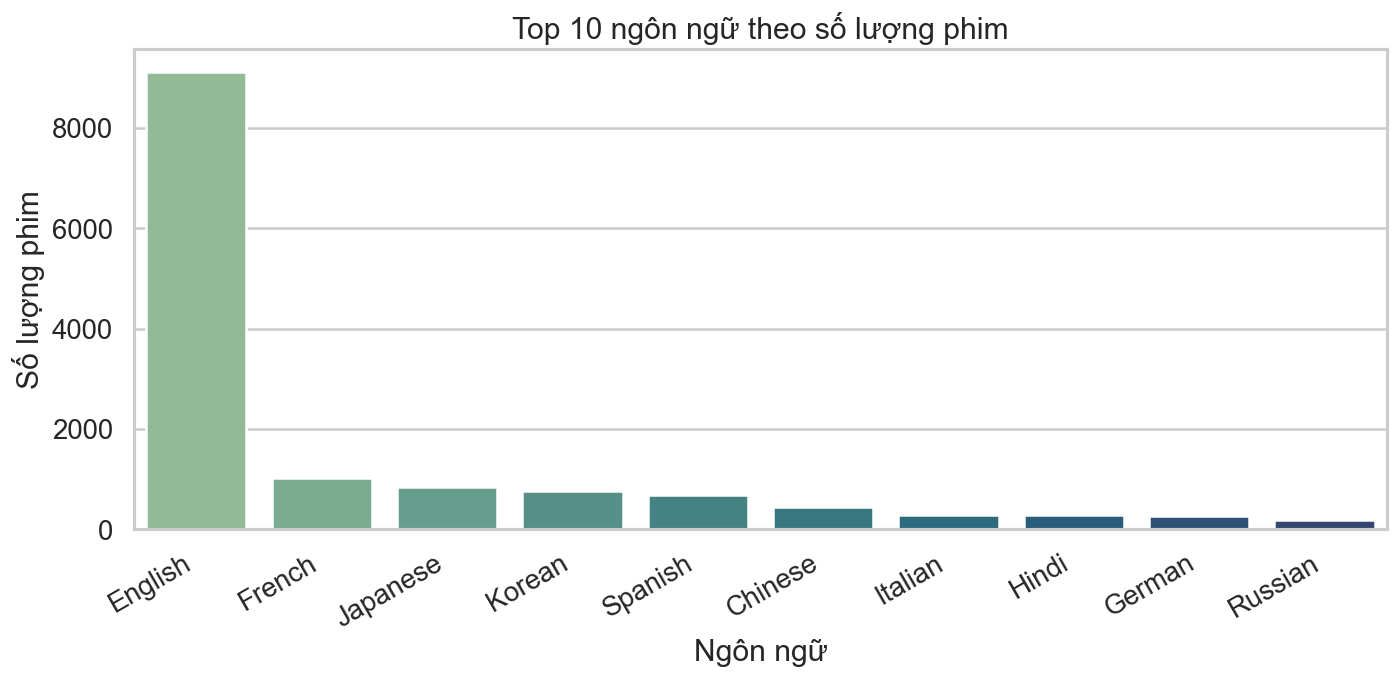

In [9]:
# 05. Top ngôn ngữ
top_languages = movies_df['language_name'].fillna('Unknown').value_counts().head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_languages.index, y=top_languages.values, palette='crest')
plt.title('Top 10 ngôn ngữ theo số lượng phim')
plt.xlabel('Ngôn ngữ')
plt.ylabel('Số lượng phim')
plt.xticks(rotation=30, ha='right')

save_and_show('05_top_languages.png')

Saved: C:\Users\ACER\Desktop\Work\Project\DataVis\Mid\Dashboard-Mid\data\outputs\slides\eda_images\06_vote_average_distribution.png


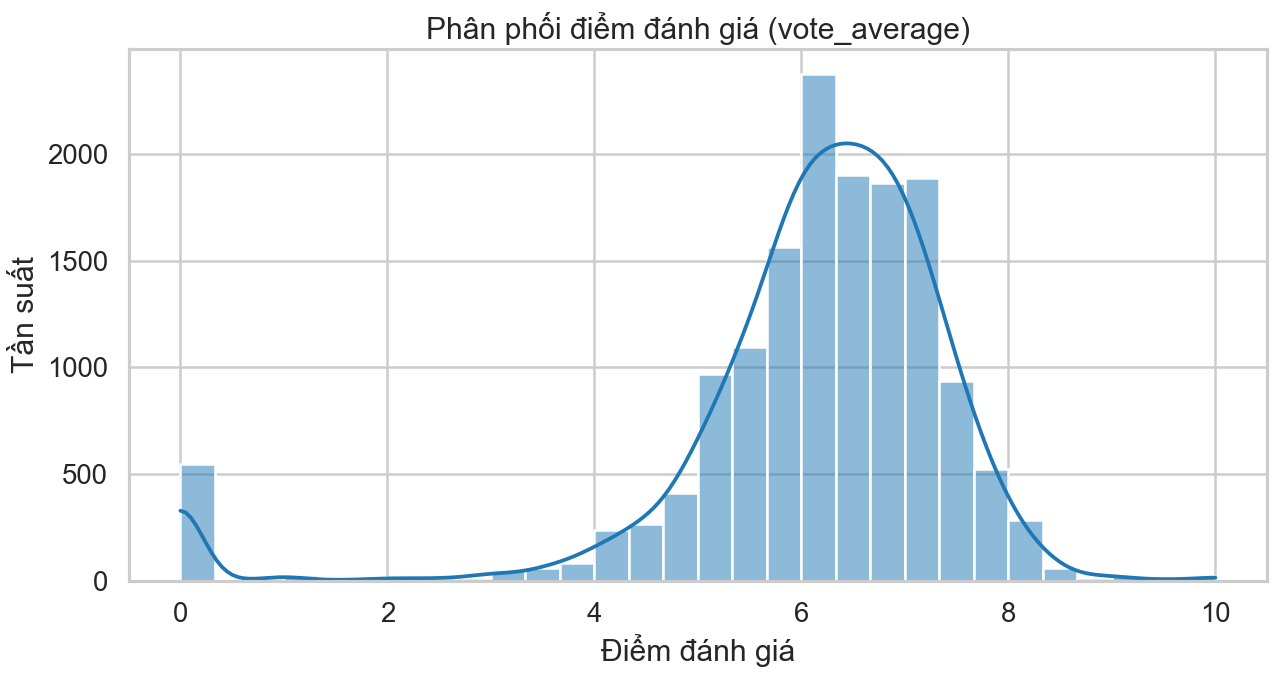

In [10]:
# 06. Phân phối điểm đánh giá
plt.figure(figsize=(11, 6))
sns.histplot(movies_df['vote_average'].dropna(), bins=30, kde=True, color='#1f77b4')
plt.title('Phân phối điểm đánh giá (vote_average)')
plt.xlabel('Điểm đánh giá')
plt.ylabel('Tần suất')

save_and_show('06_vote_average_distribution.png')

Saved: C:\Users\ACER\Desktop\Work\Project\DataVis\Mid\Dashboard-Mid\data\outputs\slides\eda_images\07_budget_vs_revenue_log.png


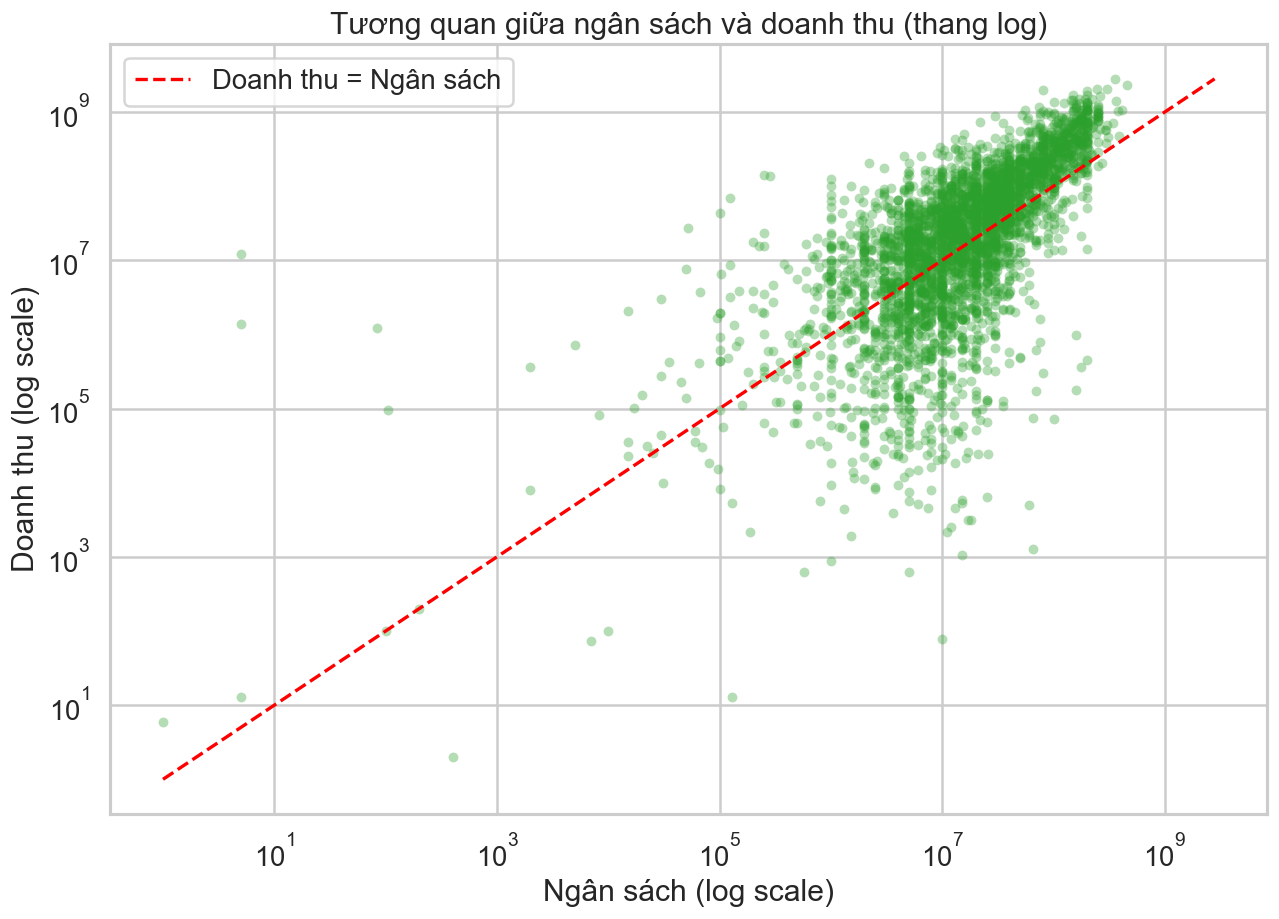

In [11]:
# 07. Tương quan ngân sách - doanh thu (log scale)
br_df = movies_df[(movies_df['budget'] > 0) & (movies_df['revenue'] > 0)].copy()

sample_size = min(8000, len(br_df))
plot_df = br_df.sample(n=sample_size, random_state=42) if len(br_df) > sample_size else br_df

plt.figure(figsize=(11, 8))
sns.scatterplot(data=plot_df, x='budget', y='revenue', alpha=0.35, s=35, color='#2ca02c', linewidth=0)
plt.xscale('log')
plt.yscale('log')

limit_max = float(max(plot_df['budget'].max(), plot_df['revenue'].max()))
plt.plot([1, limit_max], [1, limit_max], linestyle='--', color='red', linewidth=2, label='Doanh thu = Ngân sách')

plt.title('Tương quan giữa ngân sách và doanh thu (thang log)')
plt.xlabel('Ngân sách (log scale)')
plt.ylabel('Doanh thu (log scale)')
plt.legend()

save_and_show('07_budget_vs_revenue_log.png')

C:\Users\ACER\AppData\Local\Temp\ipykernel_30060\1242928804.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=roi_stat, x='roi_tb', y='genre', palette='coolwarm')
d:\Anaconda\envs\torch-gpu\Lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
d:\Anaconda\envs\torch-gpu\Lib\site-packages\seaborn\categorical.py:1273: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping column

Saved: C:\Users\ACER\Desktop\Work\Project\DataVis\Mid\Dashboard-Mid\data\outputs\slides\eda_images\08_roi_mean_by_genre.png


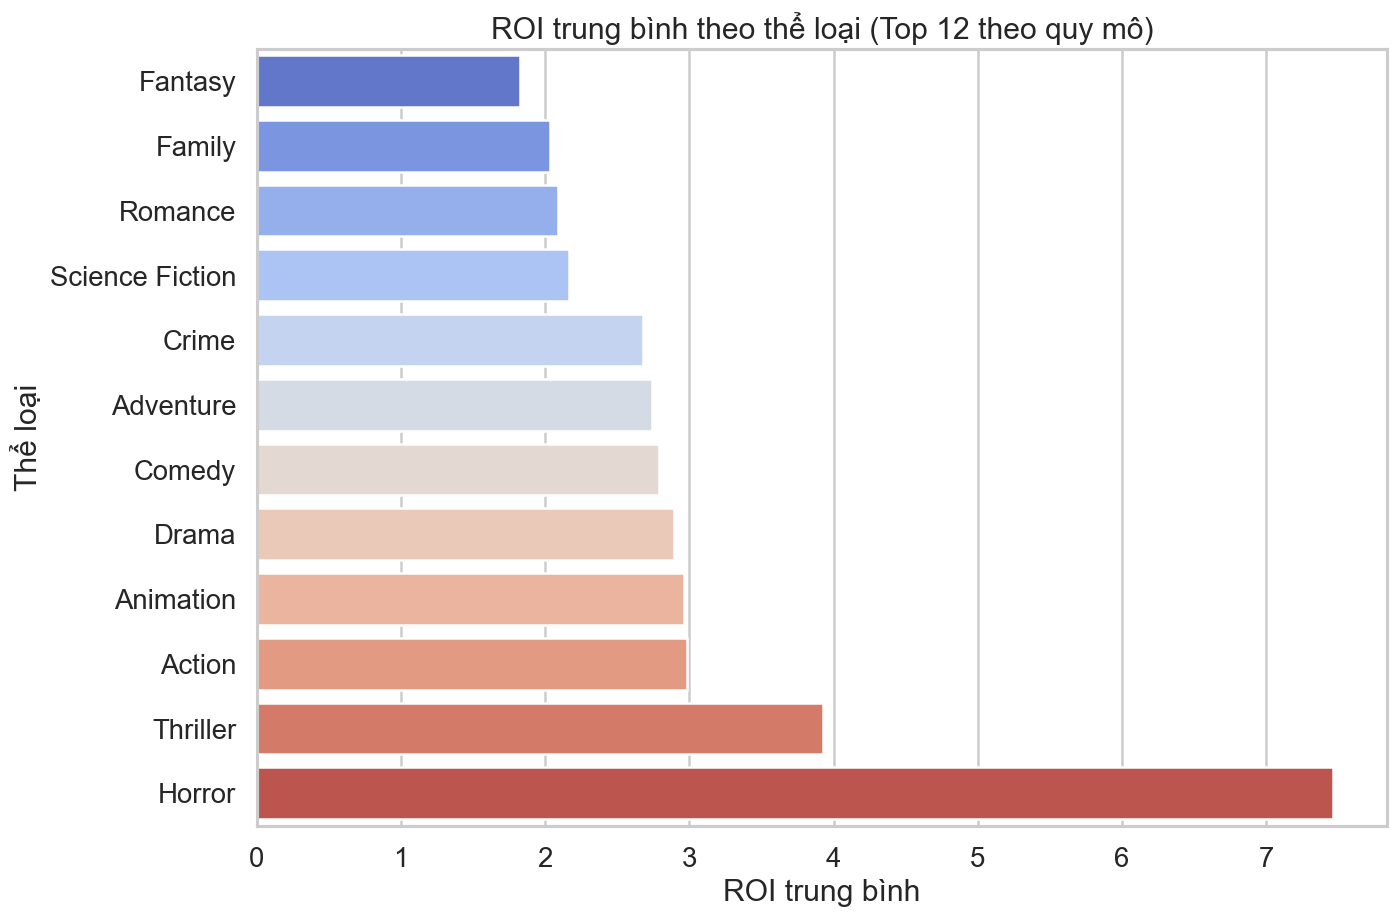

In [12]:
# 08. ROI trung bình theo thể loại (top genres)
roi_df = movies_df[(movies_df['budget'] > 5000) & (movies_df['revenue'] > 0)][['show_id', 'budget', 'revenue']].copy()
roi_df['roi'] = (roi_df['revenue'] - roi_df['budget']) / roi_df['budget']

roi_genre = roi_df.merge(genres_df, on='show_id', how='inner')
top_roi_genres = roi_genre['genre'].value_counts().head(12).index
roi_stat = (
    roi_genre[roi_genre['genre'].isin(top_roi_genres)]
    .groupby('genre', as_index=False)
    .agg(so_phim=('show_id', 'nunique'), roi_tb=('roi', 'mean'), roi_median=('roi', 'median'))
    .sort_values('roi_tb', ascending=True)
)

plt.figure(figsize=(12, 8))
sns.barplot(data=roi_stat, x='roi_tb', y='genre', palette='coolwarm')
plt.title('ROI trung bình theo thể loại (Top 12 theo quy mô)')
plt.xlabel('ROI trung bình')
plt.ylabel('Thể loại')

save_and_show('08_roi_mean_by_genre.png')

C:\Users\ACER\AppData\Local\Temp\ipykernel_30060\2622098444.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=bucket_counts.index, y=bucket_counts.values, palette='Spectral')
d:\Anaconda\envs\torch-gpu\Lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
d:\Anaconda\envs\torch-gpu\Lib\site-packages\seaborn\categorical.py:1273: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the groupin

Saved: C:\Users\ACER\Desktop\Work\Project\DataVis\Mid\Dashboard-Mid\data\outputs\slides\eda_images\09_quality_buckets.png


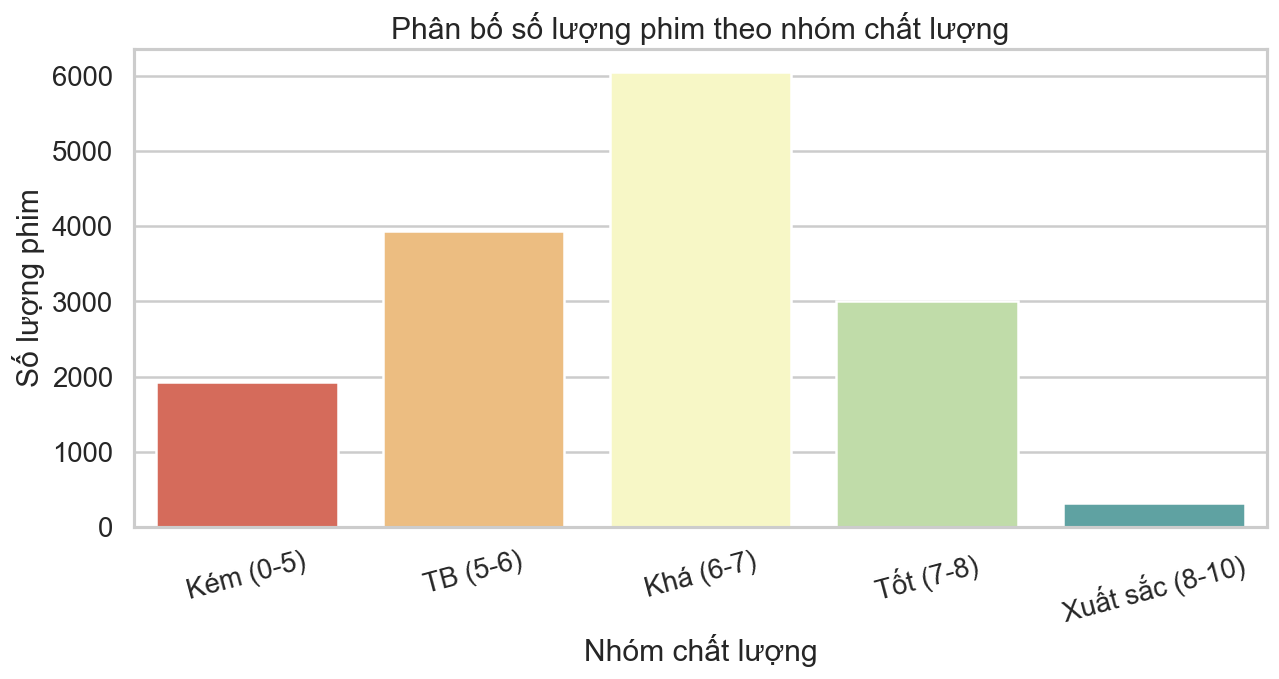

In [13]:
# 09. Nhóm chất lượng phim theo vote_average
bins = [0, 5, 6, 7, 8, 10]
labels = ['Kém (0-5)', 'TB (5-6)', 'Khá (6-7)', 'Tốt (7-8)', 'Xuất sắc (8-10)']
quality_bucket = pd.cut(movies_df['vote_average'], bins=bins, labels=labels, include_lowest=True)
bucket_counts = quality_bucket.value_counts().reindex(labels)

plt.figure(figsize=(11, 6))
sns.barplot(x=bucket_counts.index, y=bucket_counts.values, palette='Spectral')
plt.title('Phân bố số lượng phim theo nhóm chất lượng')
plt.xlabel('Nhóm chất lượng')
plt.ylabel('Số lượng phim')
plt.xticks(rotation=15)

save_and_show('09_quality_buckets.png')

In [14]:
print('Danh sách ảnh đã xuất:')
for idx, name in enumerate(generated_files, start=1):
    print(f'{idx:02d}. {name}')

print(f'\nTổng số ảnh: {len(generated_files)}')
print(f'Thư mục lưu ảnh: {OUT_DIR}')

Danh sách ảnh đã xuất:
01. 01_missing_values_raw.png
02. 02_release_year_trend.png
03. 03_top_countries.png
04. 04_top_genres.png
05. 05_top_languages.png
06. 06_vote_average_distribution.png
07. 07_budget_vs_revenue_log.png
08. 08_roi_mean_by_genre.png
09. 09_quality_buckets.png

Tổng số ảnh: 9
Thư mục lưu ảnh: C:\Users\ACER\Desktop\Work\Project\DataVis\Mid\Dashboard-Mid\data\outputs\slides\eda_images
